ML-1 Predict the price of the Uber ride from a given pickup point to the agreed drop-off location.
Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement linear regression and random forest regression models.
5. Evaluate the models and compare their respective scores like R2, RMSE, etc.

In [2]:
import pandas as pd
df = pd.read_csv("/home/admin1/uber.csv")

In [3]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 23.4 MB


In [8]:
df.shape

(200000, 9)

In [9]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [10]:
df.isna().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [4]:
df.dropna(inplace=True)

In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'] , errors = 'coerce')   #converted to datetime obj y-m-d
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

In [6]:
df.drop(['pickup_datetime', 'key'], axis=1, inplace=True, errors='ignore')

In [7]:
df.columns

Index(['Unnamed: 0', 'fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour',
       'day', 'month', 'year', 'day_of_week'],
      dtype='object')

In [8]:
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 100)] # reasonable fare


df = df[(df['pickup_latitude'] <= 90) & (df['pickup_latitude'] >= -90)]   #valid coordinates condition
df = df[(df['dropoff_latitude'] <= 90) & (df['dropoff_latitude'] >= -90)]
df = df[(df['pickup_longitude'] <= 180) & (df['pickup_longitude'] >= -180)]
df = df[(df['dropoff_longitude'] <= 180) & (df['dropoff_longitude'] >= -180)]

print("Data shape after removing outliers:", df.shape)

Data shape after removing outliers: (199875, 12)


In [9]:
import numpy as np

def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Convert all columns from decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula applied to whole arrays
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

# Calculate distance instantly without using .apply()
df['distance_km'] = haversine_vectorized(
    df['pickup_latitude'], 
    df['pickup_longitude'],
    df['dropoff_latitude'], 
    df['dropoff_longitude']
)

# Remove zero-distance trips
df = df[df['distance_km'] > 0]


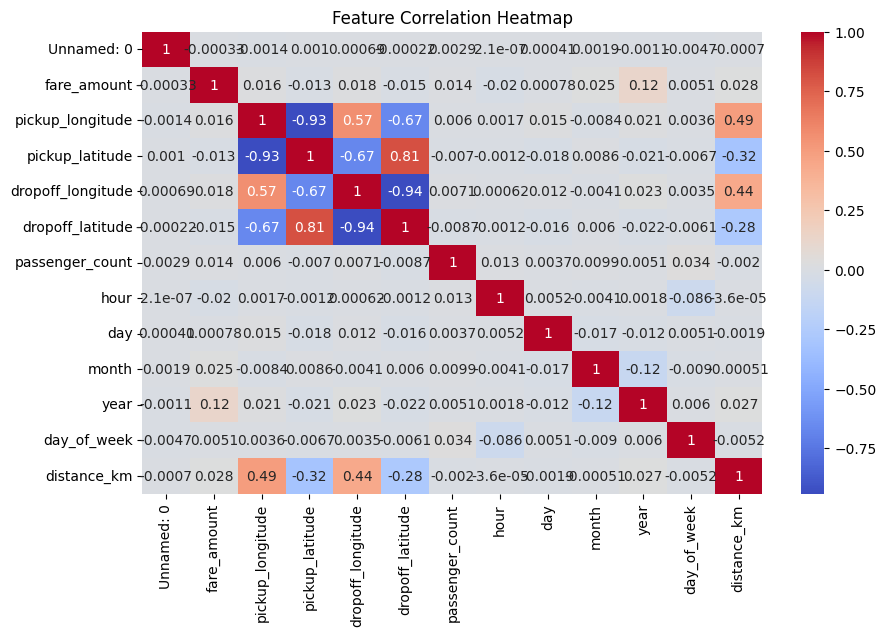

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Define features and target
X = df[['distance_km', 'hour', 'day', 'month', 'year', 'day_of_week']]
y = df['fare_amount']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------- Linear Regression --------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)



In [13]:
# -------------------- Random Forest Regression --------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [14]:
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\nModel: {model_name}")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    return r2, rmse, mae

# Evaluate both models
lr_scores = evaluate_model(y_test, y_pred_lr, "Linear Regression")
rf_scores = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")


Model: Linear Regression
R² Score: 0.0172
RMSE: 9.4318
MAE: 5.9225

Model: Random Forest Regressor
R² Score: 0.8191
RMSE: 4.0466
MAE: 2.1520


In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'R2': [lr_scores[0], rf_scores[0]],
    'RMSE': [lr_scores[1], rf_scores[1]],
    'MAE': [lr_scores[2], rf_scores[2]]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
                     Model        R2      RMSE       MAE
0        Linear Regression  0.017172  9.431814  5.922463
1  Random Forest Regressor  0.819084  4.046640  2.151991


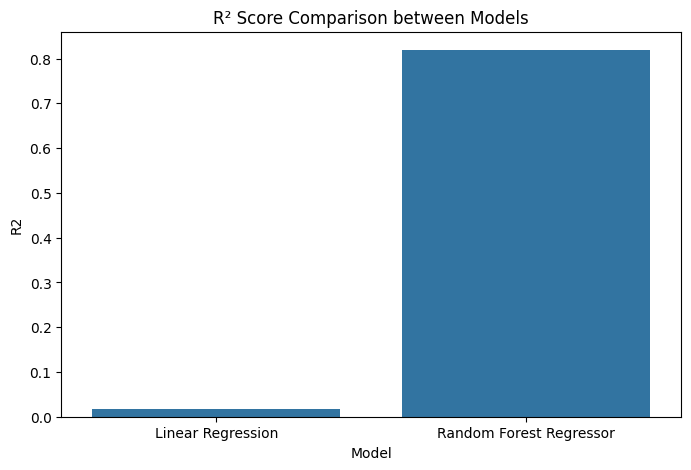

In [16]:
# Plot comparison
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2', data=results)
plt.title("R² Score Comparison between Models")
plt.show()